# Credit Card Fraud Detection - Midpoint Baseline Model
This notebook contains the exploratory data analysis (EDA), data preprocessing, and baseline Logistic Regression model for our credit card fraud detection project.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

Loading dataset...
Calculating class distribution...
Legitimate Transactions: 284315
Fraudulent Transactions: 492
Percentage of Fraud: 0.173%



/var/folders/51/kkgylr0s7vd8971v07bhrc040000gn/T/ipykernel_27422/651147145.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='pastel')


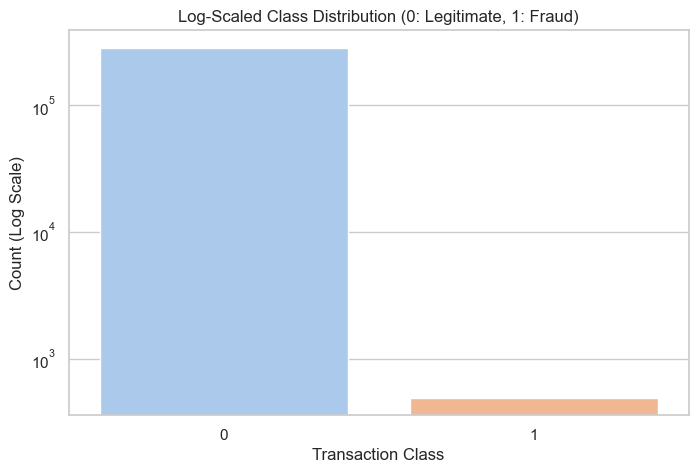

In [2]:
print("Loading dataset...")
df = pd.read_csv('creditcard.csv')

print("Calculating class distribution...")
class_counts = df['Class'].value_counts()
fraud_percentage = (class_counts[1] / len(df)) * 100
print(f"Legitimate Transactions: {class_counts[0]}")
print(f"Fraudulent Transactions: {class_counts[1]}")
print(f"Percentage of Fraud: {fraud_percentage:.3f}%\n")

plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='pastel')
plt.yscale('log')
plt.title('Log-Scaled Class Distribution (0: Legitimate, 1: Fraud)')
plt.xlabel('Transaction Class')
plt.ylabel('Count (Log Scale)')
plt.savefig('class_imbalance.png', bbox_inches='tight')
plt.show()

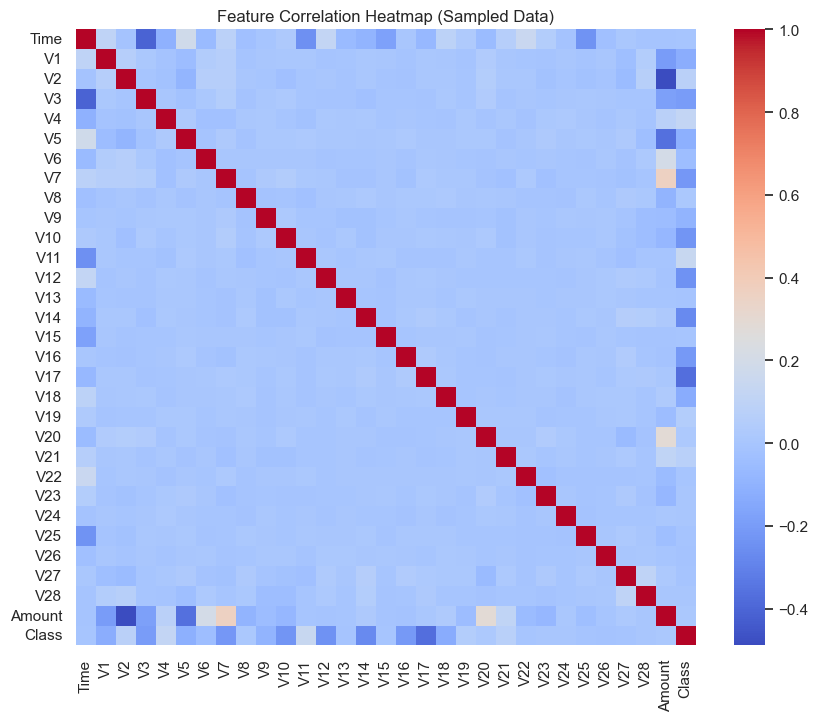

/var/folders/51/kkgylr0s7vd8971v07bhrc040000gn/T/ipykernel_27422/3466531840.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette='Set2')


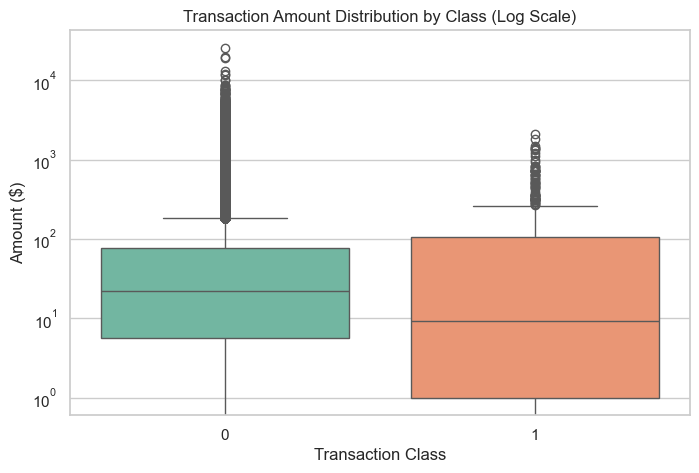

In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.sample(20000, random_state=42).corr(), cmap='coolwarm', cbar=True)
plt.title('Feature Correlation Heatmap (Sampled Data)')
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df, palette='Set2')
plt.yscale('log')
plt.title('Transaction Amount Distribution by Class (Log Scale)')
plt.xlabel('Transaction Class')
plt.ylabel('Amount ($)')
plt.savefig('amount_distribution.png', bbox_inches='tight')
plt.show()

In [4]:
print("Preprocessing data...")

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])
print("Data scaling and splitting complete.")

Preprocessing data...
Data scaling and splitting complete.


In [5]:
print("\nTraining Baseline Logistic Regression Model...")

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]
print("Model training complete.")


Training Baseline Logistic Regression Model...
Model training complete.


Evaluating Baseline Model...

--- Baseline Results ---
Precision: 0.8289
Recall:    0.6429
F1-Score:  0.7241
PR-AUC:    0.7420

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



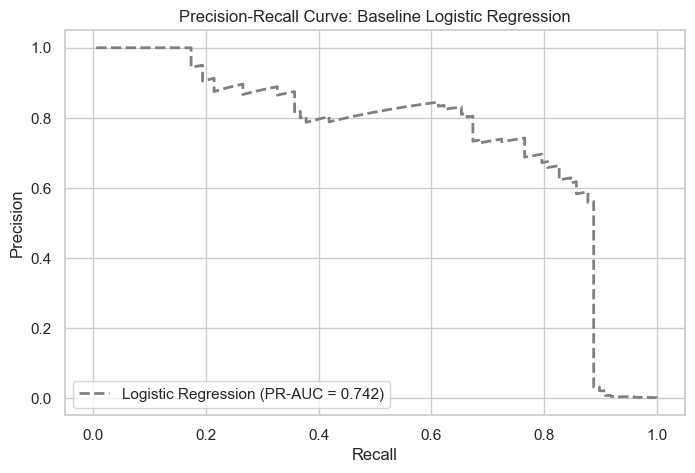

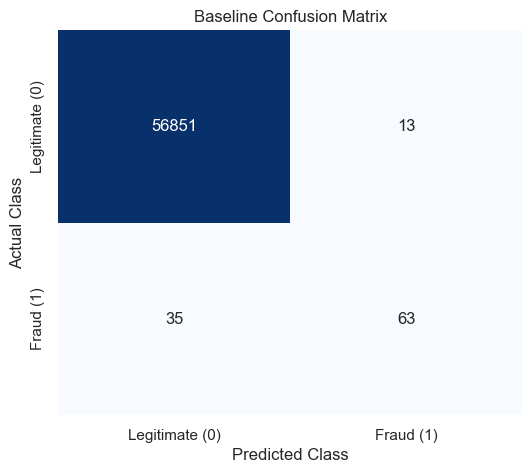

/var/folders/51/kkgylr0s7vd8971v07bhrc040000gn/T/ipykernel_27422/2925498666.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feat_imp_df.head(10), palette='coolwarm')


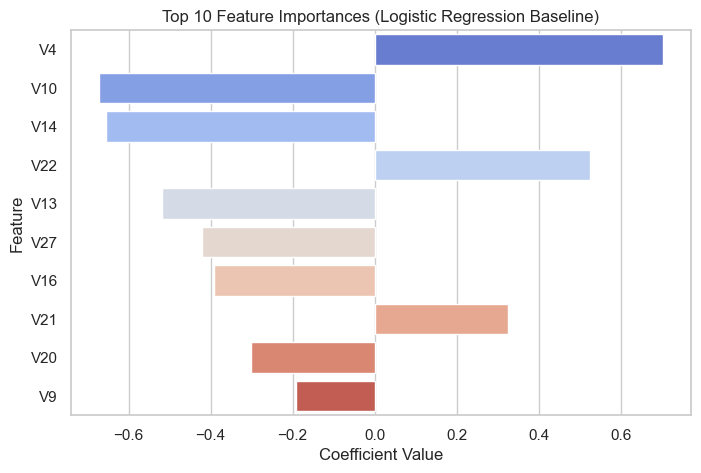

In [6]:
print("Evaluating Baseline Model...\n")

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_curve, precision_curve)

print("--- Baseline Results ---")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, label=f'Logistic Regression (PR-AUC = {pr_auc:.3f})', color='grey', linestyle='--', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Baseline Logistic Regression')
plt.legend(loc='lower left')
plt.grid(True)
plt.savefig('bl_baseline_pr_curve.png', bbox_inches='tight')
plt.show()

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate (0)', 'Fraud (1)'],
            yticklabels=['Legitimate (0)', 'Fraud (1)'])
plt.title('Baseline Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.savefig('bl_baseline_confusion_matrix.png', bbox_inches='tight')
plt.show()

importance = baseline_model.coef_[0]
feature_names = X_train.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': importance})
feat_imp_df['Abs_Coefficient'] = feat_imp_df['Coefficient'].abs()
feat_imp_df = feat_imp_df.sort_values(by='Abs_Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=feat_imp_df.head(10), palette='coolwarm')
plt.title('Top 10 Feature Importances (Logistic Regression Baseline)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.savefig('bl_baseline_feature_importance.png', bbox_inches='tight')
plt.show()

In [ ]:
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]
baseline_preds = baseline_model.predict(X_test)

baseline_prec_array, baseline_rec_array, _ = precision_recall_curve(y_test, baseline_probs)
baseline_pr_auc = auc(baseline_rec_array, baseline_prec_array)

baseline_f1 = f1_score(y_test, baseline_preds)
baseline_precision = precision_score(y_test, baseline_preds)
baseline_recall = recall_score(y_test, baseline_preds)

cm = confusion_matrix(y_test, baseline_preds)
tn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]
tp = cm[1, 1]

print("--- BASELINE LOGISTIC REGRESSION ---")
print(f"Default Threshold: 0.5000")
print(f"PR-AUC:            {baseline_pr_auc:.4f}")
print(f"F1-Score:          {baseline_f1:.4f}")
print(f"Precision:         {baseline_precision:.4f}")
print(f"Recall:            {baseline_recall:.4f}")
print(f"True Positives:    {tp} (Fraud)")
print(f"False Negatives:   {fn} (Fraud but classified legit)")
print(f"False Positives:   {fp} (Legit but classified fraud)")
print(f"True Negatives:    {tn} (Legit)")
print("------------------------------------")

--- BASELINE LOGISTIC REGRESSION ---
Default Threshold: 0.5000
PR-AUC:            0.7420
F1-Score:          0.7241
Precision:         0.8289
Recall:            0.6429
True Positives:    63 (Fraud)
False Negatives:   35 (Fraud but classified legit)
False Positives:   13 (Legit but classified fraud)
True Negatives:    56851 (Legit)
------------------------------------


In [ ]:
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]

np.savez('baseline_predictions.npz', baseline_lr=baseline_probs)
print("Baseline predictions saved!")

Baseline predictions saved!
